# Custom Dataset:

**Is a collection of built-in data relating to a specific problems you're working on**

**A custom dataset can `comprised` of anything**



# Importing and setting device agnostic code

In [11]:
import torch
from torch import nn

# setting deivce agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## Get the data

In [12]:
import requests
import zipfile
from pathlib import Path

# Define paths
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"
zip_path = data_path / "pizza_steak_sushi.zip"
url = "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip"

# Make data folder if not present
data_path.mkdir(parents=True, exist_ok=True)

# Download the dataset if not already present
if not zip_path.exists():
    print("📦 Downloading pizza_steak_sushi.zip...")
    try:
        with requests.get(url, stream=True, timeout=60) as r:
            r.raise_for_status()
            with open(zip_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
        print(f"✅ Download complete: {zip_path}")
    except requests.exceptions.RequestException as e:
        print("❌ Download failed:", e)
else:
    print("ZIP file already exists, skipping download.")

# Check file size
if zip_path.exists():
    size_mb = zip_path.stat().st_size / (1024 * 1024)
    print(f"ZIP file size: {size_mb:.2f} MB")

# Extract if not already extracted
if not image_path.exists() or not any(image_path.iterdir()):
    print("📂 Extracting data...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(image_path)
    print("✅ Extraction complete.")
else:
    print("Data already extracted.")

# Verify contents
import os
num_dirs = 0
num_files = 0
for _, dirnames, filenames in os.walk(image_path):
    num_dirs += len(dirnames)
    num_files += len(filenames)
print(f"There are {num_dirs} directories and {num_files} images in '{image_path}'.")


📦 Downloading pizza_steak_sushi.zip...
✅ Download complete: data/pizza_steak_sushi.zip
ZIP file size: 15.01 MB
📂 Extracting data...
✅ Extraction complete.
There are 8 directories and 300 images in 'data/pizza_steak_sushi'.


In [13]:
from pathlib import Path

zip_path = Path("data/pizza_steak_sushi.zip")
print("Exists:", zip_path.exists())
print("File size:", zip_path.stat().st_size if zip_path.exists() else "Not found")


Exists: True
File size: 15737296


##2. Becoming one with the data (data preperation and data exploration)


In [14]:
import os
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory

  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [15]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.


In [16]:
# Setup train and test paths
train_dir = image_path /"train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### Visualizing an image


Random_image path: data/pizza_steak_sushi/train/sushi/2797464.jpg
Image class: sushi
Image height: 512
Image width: 512


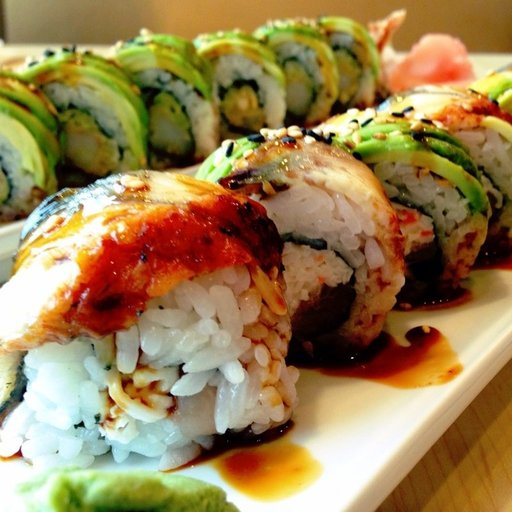

In [17]:
import random

from PIL import Image

# Set seed
random.seed(42)

# 1 Get all images paths ( * means "any combination"
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2 Get random image path
random_image_path = random.choice(image_path_list)

# 3 Get image class from the path name (the image class is the name of the dir: where the image is stored)
image_class = random_image_path.parent.stem

# 4 Open image
img = Image.open(random_image_path)

print(f"Random_image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img


**We can do the same with `matplotlib.pyplot.imshow()`, except we have to convert the image to a Numpy array first.**

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

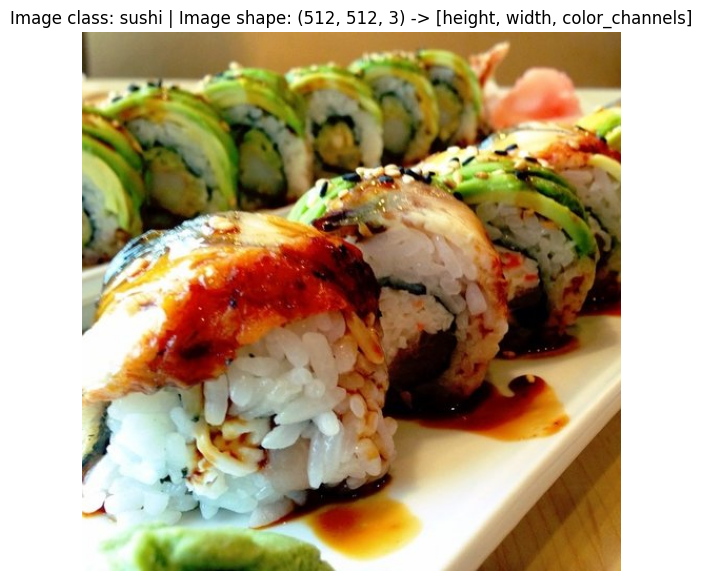

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False)

## Transforming data

Now what if we wanted to load our image data into PyTorch?
Before we can use our image data with PyTorch we need to:

>1 Turn it into tensors (numerical representations of our images)

>2.     Turn it into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`, we'll call these `Dataset` and `DataLoader` for short.



>


In [19]:
import torch
!pip install DataLoader
from torch.utils.data import DataLoader

from torchvision import datasets , transforms



  Preparing metadata (setup.py) ... done
  Created wheel for DataLoader: filename=dataloader-2.0-py3-none-any.whl size=10083 sha256=05c2bceaf693925f130f8ac5fd4d7064fc5996af9f08002bc60fc099d62d1c83
  Stored in directory: /root/.cache/pip/wheels/fa/17/c3/e258aa863dd515a9b5759c01f4af55b2a2ea0881b2778fc749
Successfully built DataLoader


In [20]:
# Write a transform for image
data_transform = transforms.Compose([
    # Resize the images to 64x64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizonatl
    transforms.RandomHorizontalFlip(p=0.5), #  p = probability of flip, 0.5 = 50% chance
    # Turn the image into a torch.Tensor
    transforms.ToTensor()

])


Here we've got the composition transfroms , let's write a function to try them out on various images.


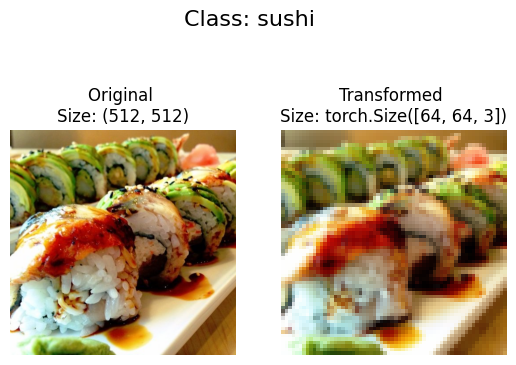

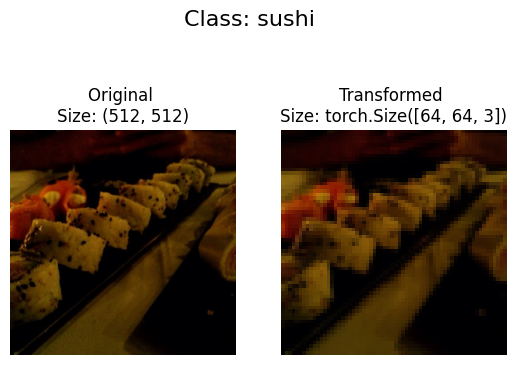

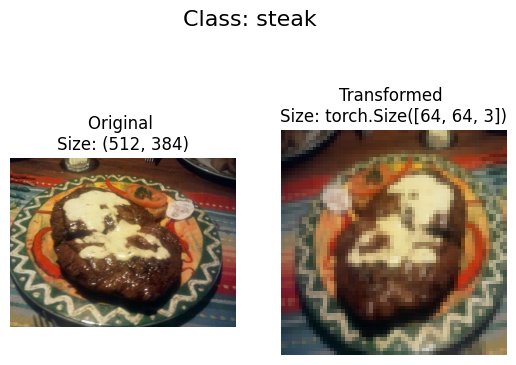

In [21]:


def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths.
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list,
                        transform=data_transform,
                        n=3)



We've now got a way to convert our images to tensors using torchvision.transforms.

We also manipulate their size and orientation if needed (some models prefer images of different sizes and shapes).

# Data visualization


# Loadng image data using the `ImageFolder`


In [22]:
# use ImageFolder to create dataset
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,  # target folder images
                                  transform=data_transform,  # transforms to perform on data (images)  #
                                  target_transform=None)   # transforms to perform on labels (if necessary)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform,
                               )





print(f"Train_data:\n{train_data}\nTest data:\n {test_data}")

Train_data:
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
 Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [23]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [24]:
# can also get class names as a dict

class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [25]:
len(train_data), len(test_data)

(225, 75)

# Index on the train_data Dataset to get a single image and label

We can index on our `train_data` and `test_data` Dataset's to find the samples and their target labels


In [26]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n {img}")
print(f"Image shape:\n {img.shape}")
print(f"Image datatype:\n {img.dtype}")
print(f"Image label: {label}")
print(f"Image datatype: {type(label)}")

Image tensor:
 tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.0

Our images are now in the form of a tensor (with shape [3, 64, 64] and the labels are in the form of an integer relating to a specific class (as referenced by the class_to_idx attribute).



Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


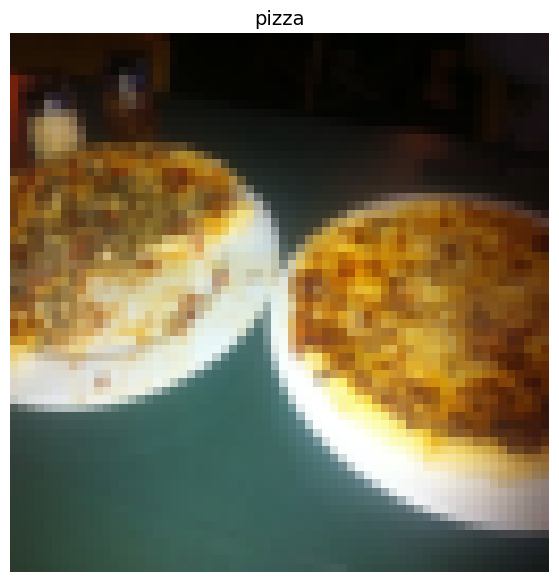

In [27]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Print out differenct shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plitting the image
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_names[label], fontsize=14);

here the image is more pixalated (less quality).

this is due to being resized from  512x512 to 64x64 pixels




# Turn loader images into data Loaders
A `DataLoader` help to turn `Dataset` to Iterable

In [28]:
# Turn train and test datasets into DataLoaders

from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=1,
                              num_workers=1, #  how many subprocesses to use for data loading? (higher = more)
                              shuffle=False)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=1,
                             num_workers=1,
                             shuffle=False)

train_dataloader, test_dataloader




(<torch.utils.data.dataloader.DataLoader at 0x7ecdded29160>,
 <torch.utils.data.dataloader.DataLoader at 0x7ecddece3e60>)

In [29]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1, try changing the batch_size parameter above and see the changes
print(f"IMage shape: {img.shape} -> [batch_size, color_channles, height, width]")
print(f"Label: {label.shape}")

IMage shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channles, height, width]
Label: torch.Size([1])


##5 . OPtion 2: Loading image Data with a custom `Dataset`


**What if pre-built `Dataset` creator like  `torchvision.datasets.ImageFolder()` didn't exist?  

Or one for your specific problem didn't exist?
Well, you could build your own.**

In [30]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List


In [31]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

## Creating a helper fn: to get class names

In [32]:
# Setup for traget dir
target_directory = train_dir
print(f" Target directory: {target_directory}")

# Get the class names from tthe target dir:
class_names_found = sorted([entry.name for entry in list(os.scandir(image_path / "train"))])
print(f"Class names found: {class_names_found}")

 Target directory: data/pizza_steak_sushi/train
Class names found: ['pizza', 'steak', 'sushi']


In [33]:
# Make the function to find classes in target directory

def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
  """Finds the class folder names in a target directory.
  Assumes target directory is in the standard image classification format.

  Args:
      directory (str): target directory to lead classification from.

  Returns:
      tuple[List[str] , Dict[str, int]: (list_of_class_names , directclass_names: idx ....))

  Example:
      find_classes("foof_images/train")
      >>> (["class_1", "class_2"], {"class_1:0, ...})
  """
  # Get the class names by scanning the target directory
  classes =sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  # Raise an error if class names not found
  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {dirctory}.")

  # Create a dict: of Index labels(computers prefer numerical rather than string labels)
  class_to_idx = {class_name: i for i, class_name in enumerate(classes)}
  return classes, class_to_idx

In [34]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### Create a custom `dataset` to replicate `ImageFolder`
 Now we're ready to build our own custom Dataset.

We'll build one to replicate the functionality of torchvision.datasets.ImageFolder().

This will be good practice, plus, it'll reveal a few of the required steps to make your own custom Dataset.

In [35]:
#  Write a custom dataset class (inherits from torch.utils.data.Dataset)
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):

    # 2. Initialize with a targ_dir and transform (optional) parameter
    def __init__(self, targ_dir: str, transform=None) -> None:

        # 3. Create class attributes
        # Get all image paths
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg")) # note: you'd have to update this if you've got .png's or .jpeg's
        # Setup transforms
        self.transform = transform
        # Create classes and class_to_idx attributes
        self.classes, self.class_to_idx = find_classes(targ_dir)

    # 4. Make function to load images
    def load_image(self, index: int) -> Image.Image:
        "Opens an image via a path and returns it."
        image_path = self.paths[index]
        return Image.open(image_path)

    # 5. Overwrite the __len__() method (optional but recommended for subclasses of torch.utils.data.Dataset)
    def __len__(self) -> int:
        "Returns the total number of samples."
        return len(self.paths)

    # 6. Overwrite the __getitem__() method (required for subclasses of torch.utils.data.Dataset)
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        "Returns one sample of data, data and label (X, y)."
        img = self.load_image(index)
        class_name  = self.paths[index].parent.name # expects path in data_folder/class_name/image.jpeg
        class_idx = self.class_to_idx[class_name]

        # Transform if necessary
        if self.transform:
            return self.transform(img), class_idx # return data, label (X, y)
        else:
            return img, class_idx # return data, label (X, y)

Before we test out our new ImageFolderCustom class, let's create some transforms to prepare our images.

In [36]:
# Augment train data
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

# Don't Augment the test data, only reshape
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

Turning the training images (contained in `train_dir()` and our testing images (contained in the `test_dir` into `Dataset` using our own `ImageFolderCustom`class.

In [37]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transform=train_transforms)

test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transform=test_transform)

train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7ecddc8cadb0>,
 <__main__.ImageFolderCustom at 0x7ecde2a75250>)

In [38]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [39]:

train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [40]:
# Check for equality amongst custom Dataset and ImageFolder Dataset.
print((len(train_data_custom) == len(train_data)) & (len(test_data_custom) == len(test_data)))
print(train_data_custom.classes==train_data.classes)
print(train_data_custom.class_to_idx==test_data.class_to_idx)


True
True
True


**Thus we have all the dataset match to the genrated one!**

## Create a function to display random Images
**Creating a helper function called `display_random_images()` that helps to visualize images in our `Dataset's`

In [41]:
# 1. Take in a Dataset as well as a list of class names
def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):

    # 2. Adjust display if n too high
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

    # 3. Set random seed
    if seed:
        random.seed(seed)

    # 4. Get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # 5. Setup plot
    plt.figure(figsize=(16, 8))

    # 6. Loop through samples and display random samples
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # 7. Adjust image tensor shape for plotting: [color_channels, height, width] -> [color_channels, height, width]
        targ_image_adjust = targ_image.permute(1, 2, 0)

        # Plot adjusted samples
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

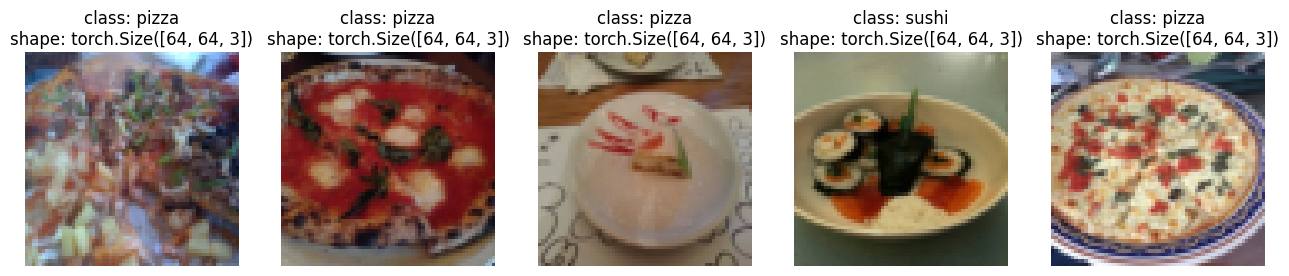

In [42]:
# Display random images from the ImageFolder created Dataset.
display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      seed=None)


For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.


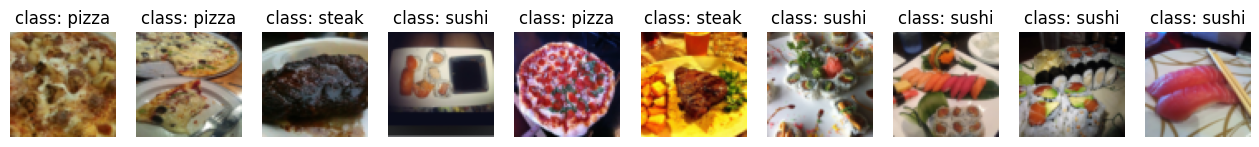

In [43]:
# Display random images from the ImageFolderCustom Dataset
display_random_images(train_data_custom,
                      n=12,
                      classes=class_names,
                      seed=None
                      )


# Turning custom loade images to dataloaders


In [44]:
# Turn train and test custom Dataset's into DataLoader's
from torch.utils.data import DataLoader
# BATCH_SIZE = 32
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=1,
                                     num_workers=0,
                                     shuffle=True)
test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size=1,
                                    num_workers=0,
                                    shuffle=False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7ecde29eb9e0>,
 <torch.utils.data.dataloader.DataLoader at 0x7ecde2a2c0e0>)

In [45]:
# Get Image and label from custom dataloader
img_custom , label_custom = next(iter(train_dataloader_custom))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
# No we set it as 32
print(f"Image shape: {img_custom.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label_custom.shape}")


# # printout the shapes
# img_custom.shape, label_custom.shape



Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


## Other forms of transforms (data augmentations)
> Is the process of artificially increasing the diversity of the dataset

> In the case of image data , this may mean applying various images transformation to the tranining images

> this process may results in a model that more generalize to an unseen data.



In [46]:
# This is trivialaugument
from torchvision import transforms

train_transform = transforms.Compose([
                                    transforms.Resize((224, 224)),
                                    transforms.TrivialAugmentWide(num_magnitude_bins=31),
                                    transforms.ToTensor(),


])

# Don't need to perform augmentation on the test data
test_teansforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])



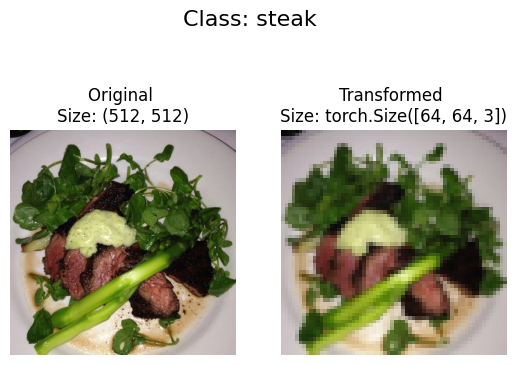

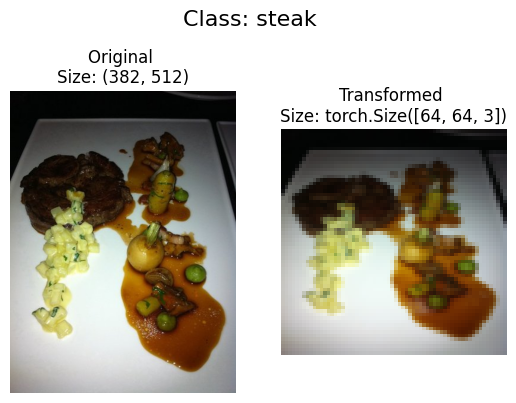

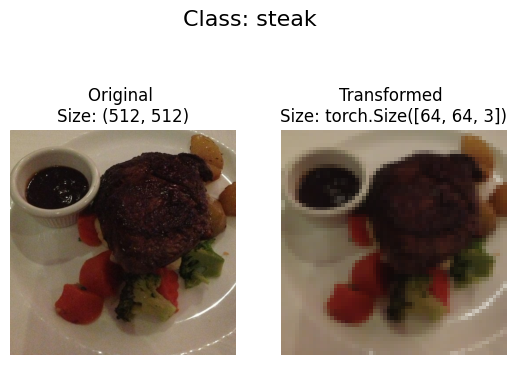

In [47]:
# Testing the data augmentation
# Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# Plot the random images
plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transforms,
    n=3,
    seed=None
)

## Model 0: TinyVGG without data augmentation

### Creating transforms and loading data for Model 0

In [48]:
simple_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

## Load and transform the data


In [49]:
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_transforms)

test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transforms)

# Turn the datasets into DataLoaders
import os
from torch.utils.data import DataLoader

# Setup batch size and number of workers
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

# Create DataLoadr's
train_dataloader_simple = DataLoader(test_data_simple,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple,
                                     batch_size=BATCH_SIZE,
                                     num_workers=NUM_WORKERS)

train_dataloader_simple, test_dataloader_simple

Creating DataLoader's with batch size 32 and 2 workers.


(<torch.utils.data.dataloader.DataLoader at 0x7ecdded26ab0>,
 <torch.utils.data.dataloader.DataLoader at 0x7ecde2948800>)

# Create TinyVGG model class

In [50]:
# The only differnce in the model we created in chapter3 and this one is that,
# here we making a 3D color images than grayscale. (in_channels=3, than that of 1)
class TinyVGG(nn.Module):

  """ Model architecture copying from TinyVGG"""

  def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
      nn.Conv2d(in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,  # how big is the square that's going over the image?
                stride=1,  # defaullt
                padding=1), # options = "vaild" (no padding) or "same" (output has same shape as input ) or int for specific number
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2,
                   stride=2) # default stride value is same as kernel_size
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.classifier =  nn.Sequential(
        nn.Flatten(),
        # It's because each layer of our network compresses and changes the shape of our input data.
        nn.Linear(in_features=hidden_units*16*16 ,
                  out_features=output_shape)

    )



  def forward(self, x: torch.Tensor):
    x = self.conv_block_1(x)
    # print(x.shape)
    x = self.conv_block_2(x)
    x = self.classifier(x)
    return x

torch.manual_seed(42)
model_0  = TinyVGG(input_shape=3,
                   hidden_units=10,
                   output_shape=len(train_data.classes)).to(device)
model_0



TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

## Try a forward pass on a single image (to test the model )


In [51]:
# 1. Get a batch of images and labels from the DataLoader
img_batch, label_batch = next(iter(train_dataloader_simple))

# 2. Get a single image from the batch and unsqueeze the image so its shape fits the model
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

# 3. Perform a forward pass on a single image
model_0.eval()
with torch.inference_mode():
    pred = model_0(img_single.to(device))

# 4. Print out what's happening and convert model logits -> pred probs -> pred label
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 64, 64])

Output logits:
tensor([[0.0678, 0.0629, 0.0395]])

Output prediction probabilities:
tensor([[0.3370, 0.3354, 0.3276]])

Output prediction label:
tensor([0])

Actual label:
1


##Use `torchinfo` to get an idea of the shapes going through our model.  

In [52]:
# install torcginfo if it's available , import it if it is
try:
  import torchinfo
except:
  !pip install torchinfo

from torchinfo import summary
summary(model_0, input_size=[1, 3, 64 , 64])  # do a test pass through of an example input size


Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

## Using `torchinfo` to get an idea of the shapes going through our model
Printing out our model with print(model) gives us an idea of what's going on with our model.

And we can print out the shapes of our data throughout the forward() method.


###  Create train & test loop functions

In [53]:
# Create train_step()
def train_step(model: torch.nn.Module,
  dataloader: torch.utils.data.DataLoader,
  loss_fn: torch.nn.Module,
  optimizer: torch.optim.Optimizer):

  # Put model in train mode
  model.train()

  train_loss, train_acc = 0.0, 0.0

  # Loop through data loader data batches
  for batch, (X, y) in enumerate(dataloader):
    # Send the data to target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    # 2 Calculate and accumulate the loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step

    # Calculate and accumulate the accuracy metrics across all batches
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  # Adjust and accumulate accuracy metrics across all batches
  y_pred_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc





In [54]:


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc



###Creating `train()` function to combine `train_step() and `test_step()` function

the same need to be done for the `test_step` and the `test_step` won't take the optimizer thus won't perform the gradient descent.

But since we'll be doing inference, we'll make sure to turn on the torch.inference_mode() context manager for making predictions.

In [55]:
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

## Train and evalute model 0


In [56]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB)
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")



  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 3.2997 | train_acc: 0.2680 | test_loss: 1.1037 | test_acc: 0.2083
Epoch: 2 | train_loss: 3.3023 | train_acc: 0.2680 | test_loss: 1.1037 | test_acc: 0.2083
Epoch: 3 | train_loss: 3.3007 | train_acc: 0.3078 | test_loss: 1.1037 | test_acc: 0.2083
Epoch: 4 | train_loss: 3.3036 | train_acc: 0.2481 | test_loss: 1.1037 | test_acc: 0.2083
Epoch: 5 | train_loss: 3.3013 | train_acc: 0.2481 | test_loss: 1.1037 | test_acc: 0.2083
Total training time: 9.914 seconds


here we can see the model is performed pretty poorly.


###Plot the loss curves of the model_0

In [60]:
# Check the model_0 results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [61]:
def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();



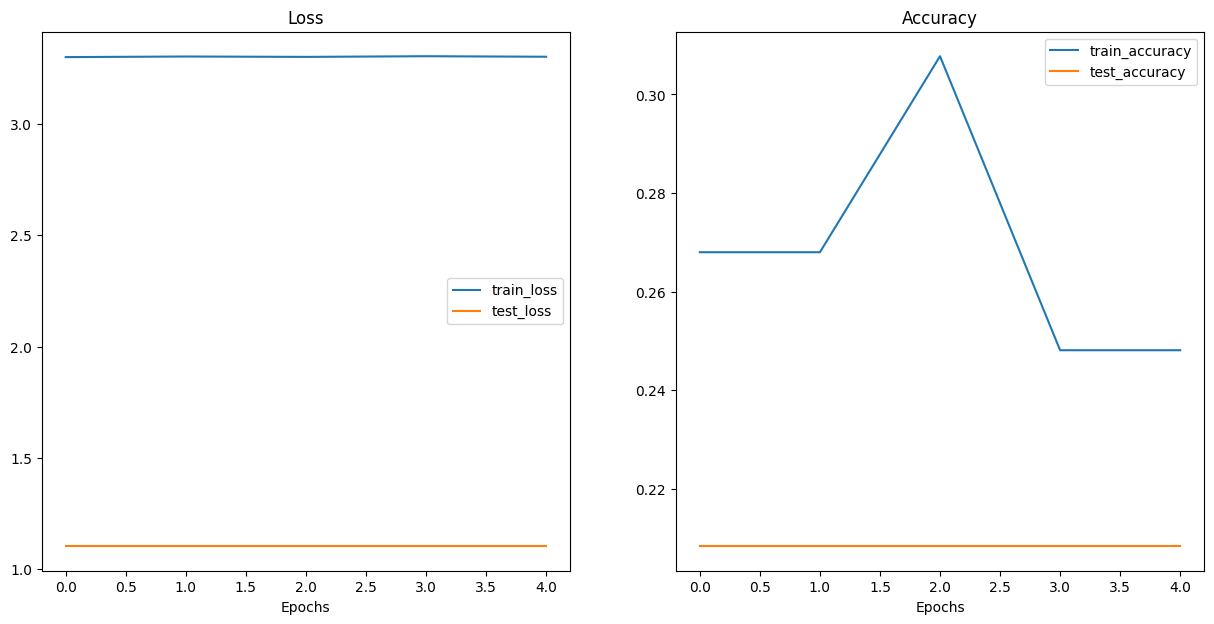

In [62]:
plot_loss_curves(model_0_results)

In [63]:
# Create a tranform with TrivialAugment
from torchvision import transforms


###Create transform with data augmentation


In [64]:
# Create training transform with TrivialAugment
train_transform_trivial_augment= transforms.Compose([
    transforms.Resize((64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

# Create testing transform (no data augmentation)
test_transfrom = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

### Create train and test `Dataset` and `DataLoader` with data augmentation


In [65]:
# Turn image folders int datasets
from torchvision import datasets
train_data_augmented = datasets.ImageFolder(train_dir,
                                            transform=train_transform_trivial_augment)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=test_transfrom)

train_data_augmented , test_data_simple


(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [66]:
# turn the Datasets into DataLoaders
import os

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()


torch.manual_seed(42)
train_dataloader_augmented = DataLoader(train_data_augmented,
                                        batch_size=BATCH_SIZE,
                                        shuffle=True,
                                        num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)

train_dataloader_augmented, test_dataloader


(<torch.utils.data.dataloader.DataLoader at 0x7ecde2e0e570>,
 <torch.utils.data.dataloader.DataLoader at 0x7ecddece3e60>)

### Construct and train model 1

**data is loaded now ..:
Now to build our next model, model_1, we can reuse our TinyVGG class from before.**

####This time using same model architecture except .......

In [67]:
# Create model_1 and send to the target device
torch.manual_seed(42)
model_1 = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data_augmented.classes)).to(device)
model_1



TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

**Thus we'va a datalpaders, let's create a loss function and optimizer and call upon our `tain()` function to train and evaluate the model**  

In [68]:
# set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
NUM_EPOCHS = 5

# setup the function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()


# Ttain te model_1
model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# end the timer and print the time it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")



  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 8.7823 | train_acc: 0.2695 | test_loss: 1.1037 | test_acc: 0.2083
Epoch: 2 | train_loss: 8.7806 | train_acc: 0.3828 | test_loss: 1.1037 | test_acc: 0.2083
Epoch: 3 | train_loss: 8.7766 | train_acc: 0.3867 | test_loss: 1.1037 | test_acc: 0.2083
Epoch: 4 | train_loss: 8.7797 | train_acc: 0.2812 | test_loss: 1.1037 | test_acc: 0.2083
Epoch: 5 | train_loss: 8.7793 | train_acc: 0.3828 | test_loss: 1.1037 | test_acc: 0.2083
Total training time: 11.957 seconds


In [69]:
model_1_results

{'train_loss': [8.782324194908142,
  8.780641436576843,
  8.776575565338135,
  8.779693126678467,
  8.779335498809814],
 'train_acc': [0.26953125, 0.3828125, 0.38671875, 0.28125, 0.3828125],
 'test_loss': [1.1037269830703735,
  1.1037269830703735,
  1.1037269830703735,
  1.1037269830703735,
  1.1037269830703735],
 'test_acc': [0.20833333333333334,
  0.20833333333333334,
  0.20833333333333334,
  0.20833333333333334,
  0.20833333333333334]}

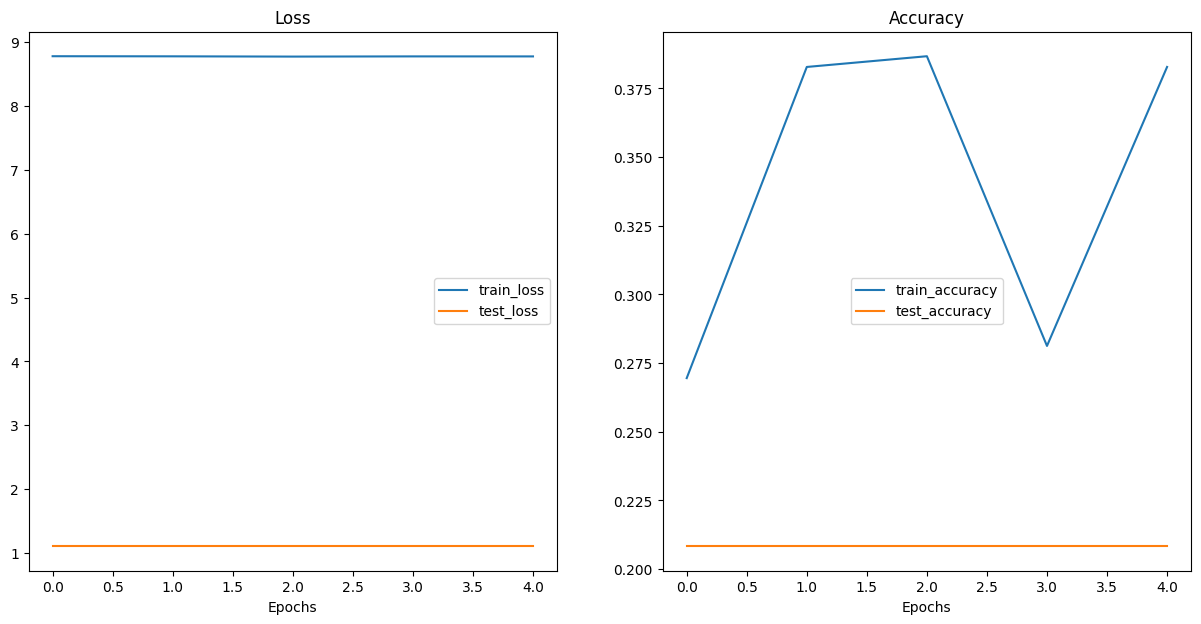

In [70]:
plot_loss_curves(model_1_results)

### PLot the loss curves to evaluate the performance overtime

### Create transform with data augmentation


## Making predictions on a custom image

In [71]:
train_transform_trivial_augment = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

# Create testing transform (no data augmentation)
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

###Create train and test `Dataset's` and `Dataloader`'s

In [72]:
# Turn Image folders into Datasets
train_data_augmented = datasets.ImageFolder(train_dir, transform=train_transform_trivial_augment)
test_data_simple = datasets.ImageFolder(test_dir, transform=test_transform)

train_data_augmented, test_data_simple

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [73]:


# Turn Datasets into DataLoader's
import os
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(train_data_augmented,
                                        batch_size=BATCH_SIZE,
                                        shuffle=True,
                                        num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)

train_dataloader_augmented, test_dataloader



(<torch.utils.data.dataloader.DataLoader at 0x7ecddc82c770>,
 <torch.utils.data.dataloader.DataLoader at 0x7ecddece3e60>)

### Construct and train model1

In [74]:
import torch

# Create model_1 and send it to the target device
torch.manual_seed(42)
model_1 = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data_augmented.classes)).to(device)
model_1



TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [75]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_1
model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 8.7823 | train_acc: 0.2695 | test_loss: 1.1037 | test_acc: 0.2083
Epoch: 2 | train_loss: 8.7806 | train_acc: 0.3828 | test_loss: 1.1037 | test_acc: 0.2083
Epoch: 3 | train_loss: 8.7766 | train_acc: 0.3867 | test_loss: 1.1037 | test_acc: 0.2083
Epoch: 4 | train_loss: 8.7797 | train_acc: 0.2812 | test_loss: 1.1037 | test_acc: 0.2083
Epoch: 5 | train_loss: 8.7793 | train_acc: 0.3828 | test_loss: 1.1037 | test_acc: 0.2083
Total training time: 13.178 seconds


###Plot the loss curves of Model 1

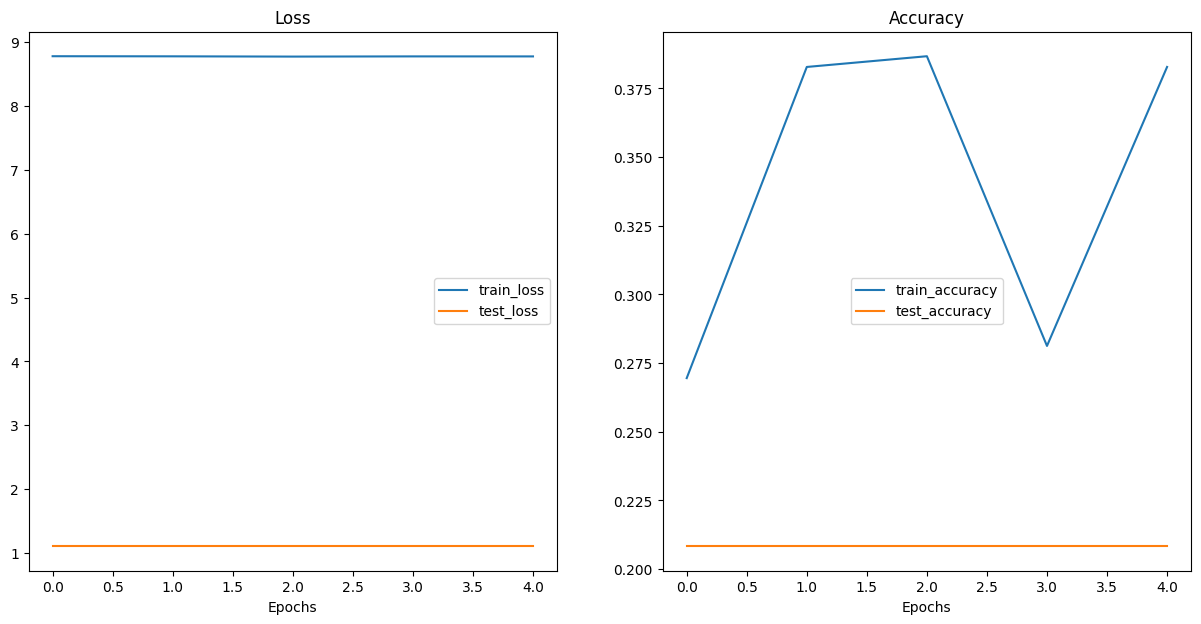

In [78]:
plot_loss_curves(model_1_results)

###Compare model results

In [76]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,3.299651,0.267992,1.103727,0.208333
1,3.302347,0.267992,1.103727,0.208333
2,3.300654,0.307765,1.103727,0.208333
3,3.303632,0.248106,1.103727,0.208333
4,3.301314,0.248106,1.103727,0.208333


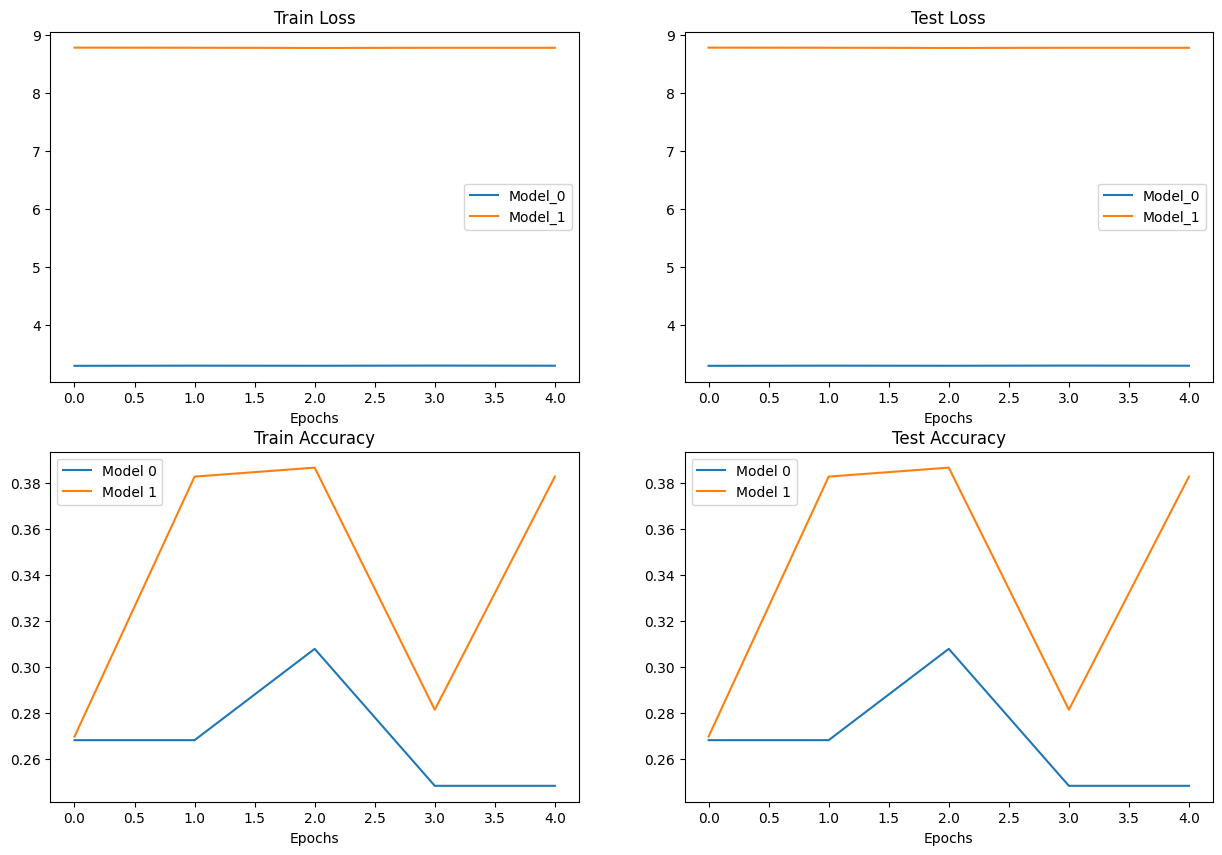

In [77]:
# Setup a plot
plt.figure(figsize=(15, 10))

# Get number of epochs
epochs = range(len(model_0_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model_0")
plt.plot(epochs, model_1_df["train_loss"], label="Model_1")
plt.title('Train Loss')
plt.xlabel('Epochs')
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["train_loss"], label="Model_0")
plt.plot(epochs, model_1_df["train_loss"], label="Model_1")
plt.title('Test Loss')
plt.xlabel('Epochs')
plt.legend()

# Plot train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()


# Plot train accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend()




## Make predictions on a custom image
**Here we use our own image and convert it to a tensor and make sure it's in the right datatype before passing it to our model**


In [79]:
# Download custom image
import requests
from  pathlib import Path
data_path = Path("data")


# Setup custom image path
custom_image_path = data_path / "04-pizza-dad.jpeg"
data_path.mkdir(parents=True, exist_ok=True)  # create the folder if it doesn't exist


# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

data/04-pizza-dad.jpeg already exists, skipping download.


###Loadng a custom image with pytorch

In [80]:
import torchvision

# Read in custom image
custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))

# Printout image data
print(f"Custom image tensor:\n {custom_image_uint8}\n")
print(f"Custom image shape:\n {custom_image_uint8.shape}\n")
print(f"Custom image dtype:\n {custom_image_uint8.dtype}\n")

Custom image tensor:
 tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)

Custom image shape:
 torch.Size([3, 4032, 3024])

Custom image d

**custom_image** tensors is of datatype **torch.unt8** and its values are between [0, 255] But our model takes image tensor of datatype `torch.float32` and with values between [0, 1]
So before we use our custom image with our model, we need to **Convert it to te same format as the data our model is trained on**


In [81]:
# Try to make a prediction on image in uint8 format (this will error)
model_1.eval()
with torch.inference_mode():
    model_1(custom_image_uint8.to(device))

RuntimeError: Input type (unsigned char) and bias type (float) should be the same

In [84]:
# Load in custom image and Convert the tensor values to float32
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32)

# Divide the image pixel values by 255 to get them between (0, 1)
custom_image = custom_image / 255

# Print out image data
print(f"Custom Image tensor : \n{custom_image}\n")
print(f"Custom Image shape : \n{custom_image.shape}\n")
print(f"Custom Image dtype : \n{custom_image.dtype}")


Custom Image tensor : 
tensor([[[0.6039, 0.6784, 0.7098,  ..., 0.0824, 0.0706, 0.0549],
         [0.5725, 0.6471, 0.7098,  ..., 0.0824, 0.0706, 0.0588],
         [0.4863, 0.5725, 0.6745,  ..., 0.0706, 0.0667, 0.0588],
         ...,
         [0.2824, 0.2314, 0.1765,  ..., 0.5961, 0.5882, 0.5804],
         [0.2510, 0.2157, 0.1608,  ..., 0.5882, 0.5765, 0.5647],
         [0.2510, 0.2353, 0.1804,  ..., 0.5843, 0.5725, 0.5608]],

        [[0.6706, 0.7451, 0.7569,  ..., 0.0863, 0.0745, 0.0588],
         [0.6392, 0.7137, 0.7569,  ..., 0.0863, 0.0745, 0.0627],
         [0.5529, 0.6392, 0.7216,  ..., 0.0745, 0.0706, 0.0627],
         ...,
         [0.2157, 0.1647, 0.1098,  ..., 0.4196, 0.4078, 0.4039],
         [0.1843, 0.1490, 0.0941,  ..., 0.4235, 0.4078, 0.4000],
         [0.1843, 0.1686, 0.1137,  ..., 0.4196, 0.4078, 0.3961]],

        [[0.4667, 0.5412, 0.5765,  ..., 0.0667, 0.0549, 0.0392],
         [0.4353, 0.5098, 0.5686,  ..., 0.0667, 0.0549, 0.0431],
         [0.3412, 0.4353, 0.5333,  

## Predicting on custom images with a trained PyTorch Model

(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

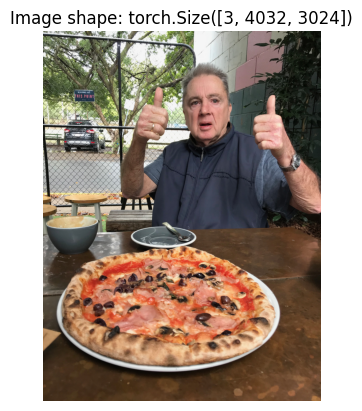

In [85]:
# plot Custom Image
plt.imshow(custom_image.permute(1, 2, 0)) # need to permute the image dims: from  CHW -> HWC otherwise matplotlib will error
plt.title(f"Image shape: {custom_image.shape}")
plt.axis(False)

In [88]:
# Create transform pipeline to resize the image
custom_image_transform = transforms.Compose([
    transforms.Resize((64, 64)),
])

# Transfrom target image
custom_image_transformed = custom_image_transform(custom_image)

# Print out original shape and new shape
print(f"Original shape: {custom_image.shape}")
print(f"New Shape:  {custom_image_transformed.shape}")

Original shape: torch.Size([3, 64, 64])
New Shape:  torch.Size([3, 64, 64])


In [89]:
model_1.eval()
with torch.inference_mode():
    custom_image_pred = model_1(custom_image_transformed)


RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x256 and 2560x3)

In [90]:
model_1.eval()
with torch.inference_mode():
    custom_image_pred = model_1(custom_image_transformed.to(device))


RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x256 and 2560x3)

These errors are because we forget the dimension the `batch_size`

Our model expects image tensors with a batch size dimension at the start (NCHW where N is the batch size).

Except our custom image is currently only CHW.
We can add a batch size dimension using torch.unsqueeze(dim=0) to add an extra dimension our image and finally make a prediction.

In [91]:
model_1.eval()

with torch.inference_mode():
  # Add an extra dimension to image
  custom_image_transformed_with_batch_size = custom_image_transformed.unsqueeze(dim=0)

  # Print out different shapes
  print(f"Custom image transformed shape: {custom_image_transformed.shape}")
  print(f"Unsqueezed custom image shape: {custom_image_transformed_with_batch_size.shape}")

  # Make a prediction on image with an extra dimension
  custom_image_pred = model_1(custom_image_transformed.unsqueeze(dim=0).to(device))

Custom image transformed shape: torch.Size([3, 64, 64])
Unsqueezed custom image shape: torch.Size([1, 3, 64, 64])


In [92]:
# Let's look at our model's predictions
custom_image_pred

tensor([[0.0626, 0.0644, 0.0374]])

These are still in logits form
Let's covert them to logits -> prediction probabilites -> prediction labels


In [93]:
# Print our prediction logits
print(f"Prediction logits: {custom_image_pred}")

# Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
print(f"Prediction probabilities: {custom_image_pred_probs}")

# Convert prediction probabilities -> prediction labels
custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)
print(f"Prediction label: {custom_image_pred_label}")



Prediction logits: tensor([[0.0626, 0.0644, 0.0374]])
Prediction probabilities: tensor([[0.3359, 0.3365, 0.3275]])
Prediction label: tensor([1])




Alright!

Looking good.

But of course our prediction label is still in index/tensor form.

We can convert it to a string class name prediction by indexing on the class_names list.


In [94]:
# Find the predicted label
custom_image_pred_class = class_names[custom_image_pred_label.cpu()] # put pred label to CPU, otherwise will error
custom_image_pred_class


'steak'

In [95]:
# The values of the prediction probabilities are quite similar
custom_image_pred_probs

tensor([[0.3359, 0.3365, 0.3275]])

## Putting custom image prediction together: building a function

**Doing all of the above steps every time you'd like to make a prediction on a custom image would quickly become tedious.**

So let's put them all together in a function we can easily use over and over again.

Specifically, let's make a function that:

    >1Takes in a target image path and converts to the right datatype for our model (torch.float32).
    >2 Makes sure the target image pixel values are in the range [0, 1].
    >3 Transforms the target image if necessary.
    >4 Makes sure the model is on the target device.
    >5 Makes a prediction on the target image with a trained model (ensuring the image is the right size and on the same device as the model).
    >6 Converts the model's output logits to prediction probabilities.
    >7 Converts the prediction probabilities to prediction labels.
    >8 Plots the target image alongside the model prediction and prediction probability.

A fair few steps but we've got this!



In [102]:


def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform=None,
                        device: torch.device = device):
    """Makes a prediction on a target image and plots the image with its prediction."""

    # 1. Load in image and convert the tensor values to float32
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

    # 2. Divide the image pixel values by 255 to get them between [0, 1]
    target_image = target_image / 255.

    # 3. Transform if necessary
    if transform:
        target_image = transform(target_image)

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Add an extra dimension to the image
        target_image = target_image.unsqueeze(dim=0)

        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(target_image.to(device))

    # 6. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 7. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 8. Plot the image alongside the prediction and prediction probability
    plt.imshow(target_image.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else:
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False);



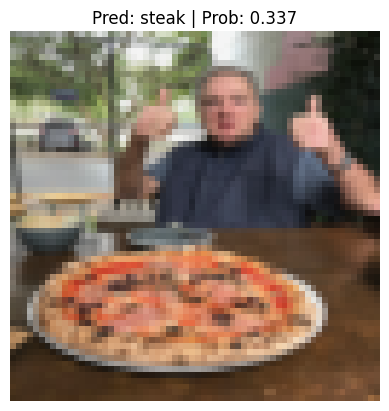

In [103]:
# Pred on our custom image
pred_and_plot_image(model=model_1,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)


##Main takeaways

###We've covered a fair bit in this module.

Let's **summarise** it with a few dot points.

    >* PyTorch has many in-built functions to deal with all kinds of data, from vision to text to audio to recommendation systems.
    > * If PyTorch's built-in data loading functions don't suit your requirements, you can write code to create your own custom datasets by subclassing torch.utils.data.Dataset.
    > * torch.utils.data.DataLoader's in PyTorch help turn your Dataset's into iterables that can be used when training and testing a model.
    > * A lot of machine learning is dealing with the balance between overfitting and underfitting (we discussed different methods for each above, so a good exercise would be to research more and writing code to try out the different techniques).
    > * Predicting on your own custom data with a trained model is possible, as long as you format the data into a similar format to what the model was trained on. Make sure you take care of the three big PyTorch and deep learning errors:
        * Wrong datatypes - Your model expected torch.float32 when your data is torch.uint8.
        * Wrong data shapes - Your model expected [batch_size, color_channels, height, width] when your data is [color_channels, height, width].
        > Wrong devices - Your model is on the GPU but your data is on the CPU.

